In [3]:
import pandas as pd 

In [4]:
orders=pd.read_csv(r'c:\Users\sayya\Downloads\olist_orders_dataset.csv.zip')
products=pd.read_csv(r'c:\Users\sayya\Downloads\olist_products_dataset.csv.zip')
review=pd.read_csv(r'c:\Users\sayya\Downloads\olist_order_reviews_dataset.csv.zip')
payments=pd.read_csv(r'c:\Users\sayya\Downloads\olist_order_payments_dataset.csv.zip')
order_item=pd.read_csv(r'c:\Users\sayya\Downloads\olist_order_items_dataset.csv.zip')
customers=pd.read_csv(r'c:\Users\sayya\Downloads\olist_customers_dataset.csv.zip')

In [5]:
def basic_check(df,orders ):
    print(f"\n{orders} DATASET")
    print("-"*40)
    print(df.head()) 
    print("Shape:", df.shape)
    print("\nMissing Values:\n", df.isnull().sum())
    print("\nDuplicates:", df.duplicated().sum())
    print("\nData Types:\n", df.dtypes)

In [6]:
basic_check(orders, "ORDERS")


ORDERS DATASET
----------------------------------------
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:

In [7]:
# Convert all date columns
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'], errors='coerce')
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'], errors='coerce')
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'], errors='coerce')
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

In [8]:
orders.dtypes

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [9]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [10]:
cols_to_ffill = [
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date'
]

for col in cols_to_ffill:
    orders[col] = orders[col].ffill()

In [11]:
orders[orders.duplicated()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date


In [12]:
orders.isnull().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64

In [13]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99441 non-null  datetime64[us]
 5   order_delivered_carrier_date   99441 non-null  datetime64[us]
 6   order_delivered_customer_date  99441 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


In [14]:
orders.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99441
mean,2017-12-31 08:43:12.776581,2017-12-31 20:23:34.460584,2018-01-05 01:00:33.728884,2018-01-14 15:01:35.991602,2018-01-24 03:08:37.730111
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00
25%,2017-09-12 14:46:19,2017-09-13 03:15:36,2017-09-18 13:50:17,2017-09-26 00:48:43,2017-10-03 00:00:00
50%,2018-01-18 23:04:36,2018-01-19 13:35:58,2018-01-24 17:49:18,2018-02-02 20:08:54,2018-02-15 00:00:00
75%,2018-05-04 15:42:16,2018-05-04 21:35:13,2018-05-08 13:51:00,2018-05-15 23:21:53,2018-05-25 00:00:00
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00


In [15]:
#products cleaning
def basic_check(df,products ):
    print(f"\n{products} DATASET")
    print("-"*40)
    print(df.head()) 
    print("Shape:", df.shape)
    print("\nMissing Values:\n", df.isnull().sum())
    print("\nDuplicates:", df.duplicated().sum())
    print("\nData Types:\n", df.dtypes)


In [16]:
basic_check(products, "PRODUCTS")


PRODUCTS DATASET
----------------------------------------
                         product_id  product_category_name  \
0  1e9e8ef04dbcff4541ed26657ea517e5             perfumaria   
1  3aa071139cb16b67ca9e5dea641aaa2f                  artes   
2  96bd76ec8810374ed1b65e291975717f          esporte_lazer   
3  cef67bcfe19066a932b7673e239eb23d                  bebes   
4  9dc1a7de274444849c219cff195d0b71  utilidades_domesticas   

   product_name_lenght  product_description_lenght  product_photos_qty  \
0                 40.0                       287.0                 1.0   
1                 44.0                       276.0                 1.0   
2                 46.0                       250.0                 1.0   
3                 27.0                       261.0                 1.0   
4                 37.0                       402.0                 4.0   

   product_weight_g  product_length_cm  product_height_cm  product_width_cm  
0             225.0               16.0       

In [17]:
# Removed irrelevant text length columns to improve data quality and reduce noise
products.drop(columns=['product_name_lenght', 'product_description_lenght'], inplace=True)

In [18]:
#filling null values
products['product_photos_qty'] = products['product_photos_qty'].fillna(products['product_photos_qty'].median())
products['product_category_name'] = products['product_category_name'].fillna('Unknown')
products['product_photos_qty'] = products['product_photos_qty'].fillna(products['product_photos_qty'].median())

In [19]:
# Dropping rows with minimal missing values to maintain data quality
products.dropna(subset=[
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
], inplace=True)

In [20]:
products.isnull().sum()

product_id               0
product_category_name    0
product_photos_qty       0
product_weight_g         0
product_length_cm        0
product_height_cm        0
product_width_cm         0
dtype: int64

In [21]:
#cheacking duplicate values
products[products.duplicated()].shape

(0, 7)

In [22]:
products.describe()

,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32949.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,2.166985,2276.472488,30.815078,16.937661,23.196728
std,1.728097,4282.038731,16.914458,13.637554,12.079047
min,1.000000,0.000000,7.000000,2.000000,6.000000
25%,1.000000,300.000000,18.000000,8.000000,15.000000
50%,1.000000,700.000000,25.000000,13.000000,20.000000
75%,3.000000,1900.000000,38.000000,21.000000,30.000000
max,20.000000,40425.000000,105.000000,105.000000,118.000000


In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

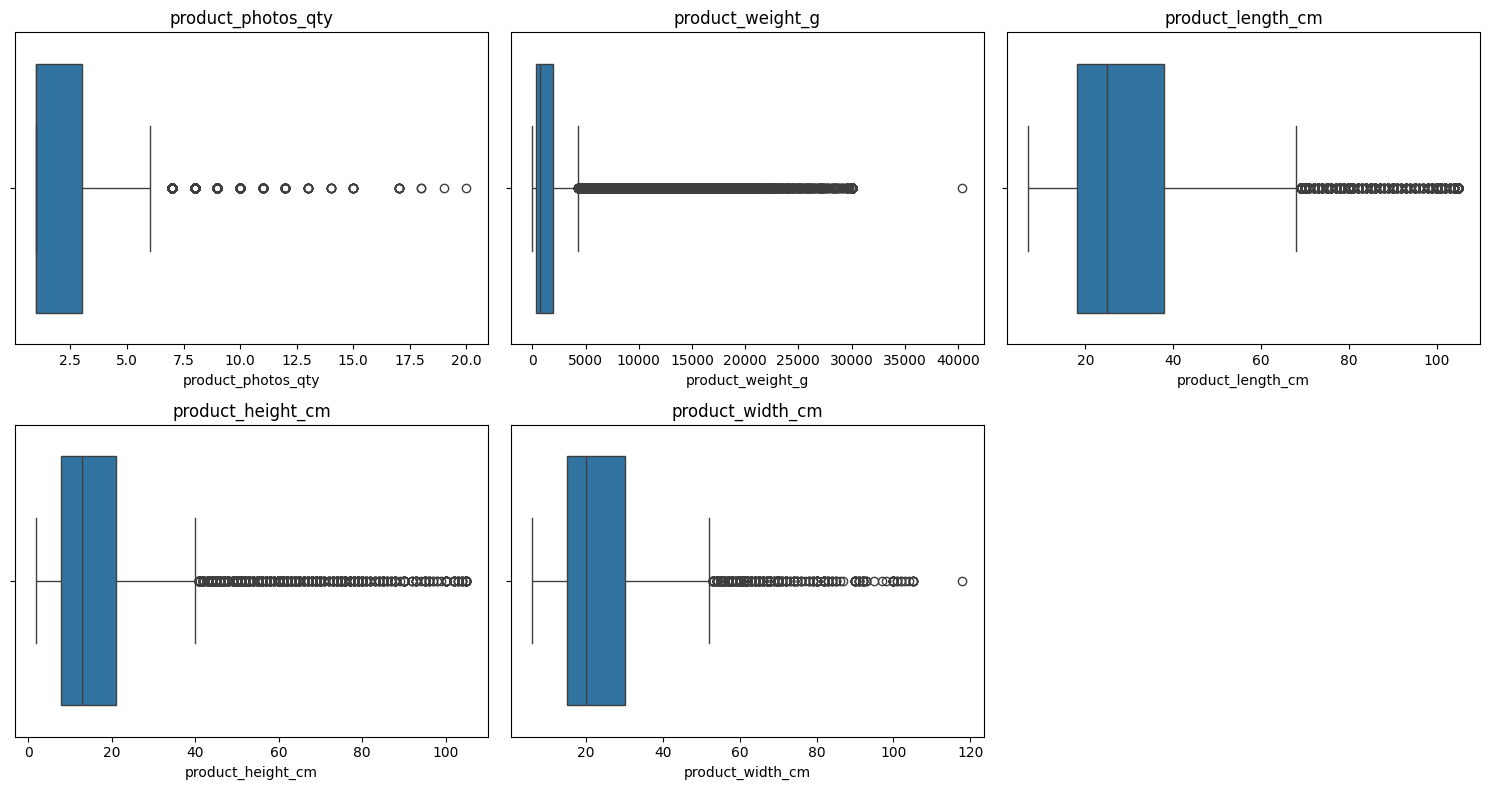

In [24]:
#Handling outliers

cols = [
    'product_photos_qty',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

plt.figure(figsize=(15,8))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=products[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [25]:
products.shape

(32949, 7)

In [26]:
import numpy as np
from scipy import stats

# Columns
zscore_cols = ['product_photos_qty', 'product_length_cm', 'product_height_cm', 'product_width_cm']
iqr_cols = ['product_weight_g']

# --- 1. Remove outliers using Z-score for normal-like columns ---
z_scores = np.abs(stats.zscore(products[zscore_cols]))
products_z_filtered = products[(z_scores < 3).all(axis=1)]

# --- 2. Remove outliers using IQR for skewed columns ---
products_filtered = products_z_filtered.copy()

for col in iqr_cols:
    Q1 = products_filtered[col].quantile(0.25)
    Q3 = products_filtered[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    products_filtered = products_filtered[(products_filtered[col] >= lower) & (products_filtered[col] <= upper)]

# --- Result ---
print("Original rows:", len(products))
print("Rows after outlier removal:", len(products_filtered))

Original rows: 32949
Rows after outlier removal: 26923


In [27]:
# Replace original data with cleaned data
products = products_filtered

# Check
print("Rows after outlier removal:", len(products))

Rows after outlier removal: 26923


In [28]:
products.shape

(26923, 7)

In [29]:
# review cleaning
def basic_check(df,review ):
    print(f"\n{review} DATASET")
    print("-"*40)
    print(df.head()) 
    print("Shape:", df.shape)
    print("\nMissing Values:\n", df.isnull().sum())
    print("\nDuplicates:", df.duplicated().sum())
    print("\nData Types:\n", df.dtypes)

In [30]:
basic_check(review,"REVIEW" )


REVIEW DATASET
----------------------------------------
                          review_id                          order_id  \
0  7bc2406110b926393aa56f80a40eba40  73fc7af87114b39712e6da79b0a377eb   
1  80e641a11e56f04c1ad469d5645fdfde  a548910a1c6147796b98fdf73dbeba33   
2  228ce5500dc1d8e020d8d1322874b6f0  f9e4b658b201a9f2ecdecbb34bed034b   
3  e64fb393e7b32834bb789ff8bb30750e  658677c97b385a9be170737859d3511b   
4  f7c4243c7fe1938f181bec41a392bdeb  8e6bfb81e283fa7e4f11123a3fb894f1   

   review_score review_comment_title  \
0             4                  NaN   
1             5                  NaN   
2             5                  NaN   
3             5                  NaN   
4             5                  NaN   

                              review_comment_message review_creation_date  \
0                                                NaN  2018-01-18 00:00:00   
1                                                NaN  2018-03-10 00:00:00   
2                               

In [31]:
#droping this text column because we dont need this column to nalysis
review= review.drop(columns=['review_comment_title', 'review_comment_message'])

In [32]:
review.columns

Index(['review_id', 'order_id', 'review_score', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='str')

In [33]:
#convert the format

review['review_creation_date'] = pd.to_datetime(review['review_creation_date'], errors='coerce')
review['review_answer_timestamp'] = pd.to_datetime(review['review_answer_timestamp'], errors='coerce')


In [34]:
review.describe()

,review_score,review_creation_date,review_answer_timestamp
count,99224.000000,99224,99224
mean,4.086421,2018-01-12 20:49:23.948238,2018-01-16 00:23:56.977939
min,1.000000,2016-10-02 00:00:00,2016-10-07 18:32:28
25%,4.000000,2017-09-23 00:00:00,2017-09-27 01:53:27.250000
50%,5.000000,2018-02-02 00:00:00,2018-02-04 22:41:47.500000
75%,5.000000,2018-05-16 00:00:00,2018-05-20 12:11:21.500000
max,5.000000,2018-08-31 00:00:00,2018-10-29 12:27:35
std,1.347579,NaN,NaN


In [35]:
#payments cleaning
def basic_check(df,payments ):
    print(f"\n{payments} DATASET")
    print("-"*40)
    print(df.head()) 
    print("Shape:", df.shape)
    print("\nMissing Values:\n", df.isnull().sum())
    print("\nDuplicates:", df.duplicated().sum())
    print("\nData Types:\n", df.dtypes)


In [36]:
basic_check(payments,"payments" )


payments DATASET
----------------------------------------
                           order_id  payment_sequential payment_type  \
0  b81ef226f3fe1789b1e8b2acac839d17                   1  credit_card   
1  a9810da82917af2d9aefd1278f1dcfa0                   1  credit_card   
2  25e8ea4e93396b6fa0d3dd708e76c1bd                   1  credit_card   
3  ba78997921bbcdc1373bb41e913ab953                   1  credit_card   
4  42fdf880ba16b47b59251dd489d4441a                   1  credit_card   

   payment_installments  payment_value  
0                     8          99.33  
1                     1          24.39  
2                     1          65.71  
3                     8         107.78  
4                     2         128.45  
Shape: (103886, 5)

Missing Values:
 order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Duplicates: 0

Data Types:
 order_id                    str
payment_sequential   

In [37]:
# in this there are no any null values,no duplicate and data type also correct

In [38]:
#order_item cleaning
def basic_check(df,order_item ):
    print(f"\n{order_item} DATASET")
    print("-"*40)
    print(df.head()) 
    print("Shape:", df.shape)
    print("\nMissing Values:\n", df.isnull().sum())
    print("\nDuplicates:", df.duplicated().sum())
    print("\nData Types:\n", df.dtypes)

In [39]:
basic_check(order_item,"order_item" )


order_item DATASET
----------------------------------------
                           order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   
2  000229ec398224ef6ca0657da4fc703e              1   
3  00024acbcdf0a6daa1e931b038114c75              1   
4  00042b26cf59d7ce69dfabb4e55b4fd9              1   

                         product_id                         seller_id  \
0  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   
2  c777355d18b72b67abbeef9df44fd0fd  5b51032eddd242adc84c38acab88f23d   
3  7634da152a4610f1595efa32f14722fc  9d7a1d34a5052409006425275ba1c2b4   
4  ac6c3623068f30de03045865e4e10089  df560393f3a51e74553ab94004ba5c87   

   shipping_limit_date   price  freight_value  
0  2017-09-19 09:45:35   58.90          13.29  
1  2017-05-03 11:05:13  239.90          19.93  
2  2018-01-18 14:48:30  199.00 

In [40]:
# all is right but we have to change shipping_limit_date fromat 

order_item['shipping_limit_date'] = pd.to_datetime(order_item['shipping_limit_date'], errors='coerce')

In [41]:
order_item.info

<bound method DataFrame.info of                                 order_id  order_item_id  \
0       00010242fe8c5a6d1ba2dd792cb16214              1   
1       00018f77f2f0320c557190d7a144bdd3              1   
2       000229ec398224ef6ca0657da4fc703e              1   
3       00024acbcdf0a6daa1e931b038114c75              1   
4       00042b26cf59d7ce69dfabb4e55b4fd9              1   
...                                  ...            ...   
112645  fffc94f6ce00a00581880bf54a75a037              1   
112646  fffcd46ef2263f404302a634eb57f7eb              1   
112647  fffce4705a9662cd70adb13d4a31832d              1   
112648  fffe18544ffabc95dfada21779c9644f              1   
112649  fffe41c64501cc87c801fd61db3f6244              1   

                              product_id                         seller_id  \
0       4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1       e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   
2       c777355d18b72b67a

In [42]:
order_item.describe()

,order_item_id,shipping_limit_date,price,freight_value
count,112650.000000,112650,112650.000000,112650.000000
mean,1.197834,2018-01-07 15:36:52.192685,120.653739,19.990320
min,1.000000,2016-09-19 00:15:34,0.850000,0.000000
25%,1.000000,2017-09-20 20:57:27.500000,39.900000,13.080000
50%,1.000000,2018-01-26 13:59:35,74.990000,16.260000
75%,1.000000,2018-05-10 14:34:00.750000,134.900000,21.150000
max,21.000000,2020-04-09 22:35:08,6735.000000,409.680000
std,0.705124,NaN,183.633928,15.806405


In [43]:
#customers cleaning
def basic_check(df,customers ):
    print(f"\n{customers} DATASET")
    print("-"*40)
    print(df.head()) 
    print("Shape:", df.shape)
    print("\nMissing Values:\n", df.isnull().sum())
    print("\nDuplicates:", df.duplicated().sum())
    print("\nData Types:\n", df.dtypes)

In [44]:
basic_check(customers,"customers" )



customers DATASET
----------------------------------------
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  
Shape: (99441, 5)

Missing Values:
 customer_id                 0
customer_unique_id         

In [45]:
print(customers['customer_state'].unique())

<StringArray>
['SP', 'SC', 'MG', 'PR', 'RJ', 'RS', 'PA', 'GO', 'ES', 'BA', 'MA', 'MS', 'CE',
 'DF', 'RN', 'PE', 'MT', 'AM', 'AP', 'AL', 'RO', 'PB', 'TO', 'PI', 'AC', 'SE',
 'RR']
Length: 27, dtype: str


In [46]:
# Abbreviation → Full form mapping

state_map = {
    'AC': 'Acre',
    'AL': 'Alagoas',
    'AP': 'Amapa',
    'AM': 'Amazonas',
    'BA': 'Bahia',
    'CE': 'Ceará',
    'DF': 'Distrito Federal',
    'ES': 'Espirito Santo',
    'GO': 'Goias',
    'MA': 'Maranhao',
    'MT': 'Mato Grosso',
    'MS': 'Mato Grosso do Sul',
    'MG': 'Minas Gerais',
    'PA': 'Para',
    'PB': 'Paraiba',
    'PR': 'Parana',
    'PE': 'Pernambuco',
    'PI': 'Piaui',
    'RJ': 'Rio de Janeiro',
    'RN': 'Rio Grande do Norte',
    'RS': 'Rio Grande do Sul',
    'RO': 'Rondônia',
    'RR': 'Roraima',
    'SC': 'Santa Catarina',
    'SP': 'Sao Paulo',
    'SE': 'Sergipe',
    'TO': 'Tocantins'
}

# ✅ Option 1: New column create (recommended)
customers['customer_state_full'] = customers['customer_state'].map(state_map)

# ✅ Option 2: Original column replace (safe way)
customers['customer_state'] = customers['customer_state'].map(state_map).fillna(customers['customer_state'])

# 🔍 Check output
print(customers[['customer_state', 'customer_state_full']].head(10))

# 🔍 Check missing values (important)
print("\nMissing values after mapping:")
print(customers['customer_state'].isnull().sum())

   customer_state customer_state_full
0       Sao Paulo           Sao Paulo
1       Sao Paulo           Sao Paulo
2       Sao Paulo           Sao Paulo
3       Sao Paulo           Sao Paulo
4       Sao Paulo           Sao Paulo
5  Santa Catarina      Santa Catarina
6       Sao Paulo           Sao Paulo
7    Minas Gerais        Minas Gerais
8          Parana              Parana
9    Minas Gerais        Minas Gerais

Missing values after mapping:
0


In [47]:
customers.drop(columns=['customer_state_full'], inplace=True)

In [48]:
customers.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='str')

In [49]:
# now marge the all data

In [68]:
# Step 1: orders + customers
df = orders.merge(customers, on='customer_id', how='left')

# Step 2: add order items
df = df.merge(order_item, on='order_id', how='left')

# Step 3: add products
df = df.merge(products, on='product_id', how='left')

# Step 4: add payments
df = df.merge(payments, on='order_id', how='left')

# Step 5: add reviews
df = df.merge(review, on='order_id', how='left')

In [69]:
df.shape
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 32 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       119143 non-null  str           
 1   customer_id                    119143 non-null  str           
 2   order_status                   119143 non-null  str           
 3   order_purchase_timestamp       119143 non-null  datetime64[us]
 4   order_approved_at              119143 non-null  datetime64[us]
 5   order_delivered_carrier_date   119143 non-null  datetime64[us]
 6   order_delivered_customer_date  119143 non-null  datetime64[us]
 7   order_estimated_delivery_date  119143 non-null  datetime64[us]
 8   customer_unique_id             119143 non-null  str           
 9   customer_zip_code_prefix       119143 non-null  int64         
 10  customer_city                  119143 non-null  str           
 11  customer_st

In [52]:
df.duplicated().sum()

np.int64(0)

In [53]:
# null values check
df.isnull().sum()

order_id                             0
customer_id                          0
order_status                         0
order_purchase_timestamp             0
order_approved_at                    0
order_delivered_carrier_date         0
order_delivered_customer_date        0
order_estimated_delivery_date        0
customer_unique_id                   0
customer_zip_code_prefix             0
customer_city                        0
customer_state                       0
order_item_id                      833
product_id                         833
seller_id                          833
shipping_limit_date                833
price                              833
freight_value                      833
product_category_name            21611
product_photos_qty               21611
product_weight_g                 21611
product_length_cm                21611
product_height_cm                21611
product_width_cm                 21611
payment_sequential                   3
payment_type             

In [66]:
# Convert review dates to datetime
df['review_creation_date'] = pd.to_datetime(df['review_creation_date'], errors='coerce')
df['review_answer_timestamp'] = pd.to_datetime(df['review_answer_timestamp'], errors='coerce')

# Shipping date to datetime
df['shipping_limit_date'] = pd.to_datetime(df['shipping_limit_date'], errors='coerce')

# Fill missing numerical values (optional, for simplicity)
num_cols = [ 'product_photos_qty','product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
df[num_cols] = df[num_cols].fillna(0)

# Fill missing review scores with 0 if needed
df['review_score'] = df['review_score'].fillna(0)
# Product category missing → fill with 'others'
df['product_category_name'] = df['product_category_name'].fillna('others')

# Drop rows missing critical order/product info
df = df.dropna(subset=['order_item_id', 'product_id', 'price'])

# Optional: delivery analysis → drop rows with missing delivery dates
df_delivery = df.dropna(subset=['order_delivered_customer_date'])

In [67]:
df.isnull().sum()

order_id                           0
customer_id                        0
order_status                       0
order_purchase_timestamp           0
order_approved_at                  0
order_delivered_carrier_date       0
order_delivered_customer_date      0
order_estimated_delivery_date      0
customer_unique_id                 0
customer_zip_code_prefix           0
customer_city                      0
customer_state                     0
order_item_id                      0
product_id                         0
seller_id                          0
shipping_limit_date                0
price                              0
freight_value                      0
product_category_name              0
product_photos_qty                 0
product_weight_g                   0
product_length_cm                  0
product_height_cm                  0
product_width_cm                   0
payment_sequential                 3
payment_type                       3
payment_installments               3
p

In [70]:
# Delivery time in days (only rows with delivery date)
df_delivery['delivery_time_days'] = (df_delivery['order_delivered_customer_date'] - df_delivery['order_purchase_timestamp']).dt.days

# Monthly / Yearly trends
df_delivery['order_month'] = df_delivery['order_purchase_timestamp'].dt.to_period('M')
df_delivery['order_year'] = df_delivery['order_purchase_timestamp'].dt.year

# Revenue per order (price + freight)
df_delivery['total_order_value'] = df_delivery['price'] + df_delivery['freight_value']

# High-level categorical for analysis
df_delivery['is_express_delivery'] = df_delivery['delivery_time_days'].apply(lambda x: 'Fast' if x <= 5 else 'Normal')

In [71]:
print("Shape of final EDA-ready dataset:", df_delivery.shape)
print("\nMissing values per column:\n", df_delivery.isnull().sum())

Shape of final EDA-ready dataset: (118310, 37)

Missing values per column:
 order_id                           0
customer_id                        0
order_status                       0
order_purchase_timestamp           0
order_approved_at                  0
order_delivered_carrier_date       0
order_delivered_customer_date      0
order_estimated_delivery_date      0
customer_unique_id                 0
customer_zip_code_prefix           0
customer_city                      0
customer_state                     0
order_item_id                      0
product_id                         0
seller_id                          0
shipping_limit_date                0
price                              0
freight_value                      0
product_category_name              0
product_photos_qty                 0
product_weight_g                   0
product_length_cm                  0
product_height_cm                  0
product_width_cm                   0
payment_sequential                 3

  order_month  total_orders  total_revenue
0     2016-09             3         354.75
1     2016-10           308       58730.85
2     2016-12             1          19.62
3     2017-01           789      148030.11
4     2017-02          1733      303648.31


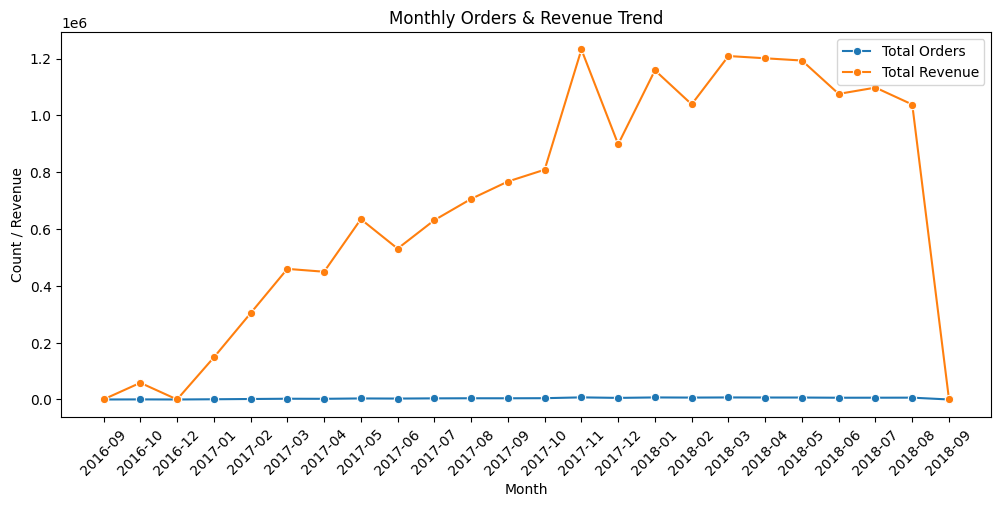

In [72]:
# Orders and revenue trend by month
monthly_trend = df_delivery.groupby('order_month').agg({
    'order_id':'nunique',
    'total_order_value':'sum'
}).reset_index().rename(columns={'order_id':'total_orders', 'total_order_value':'total_revenue'})

print(monthly_trend.head())

# Convert Period to string for plotting
monthly_trend['order_month_str'] = monthly_trend['order_month'].astype(str)

plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_trend, x='order_month_str', y='total_orders', marker='o', label='Total Orders')
sns.lineplot(data=monthly_trend, x='order_month_str', y='total_revenue', marker='o', label='Total Revenue')
plt.xticks(rotation=45)
plt.title('Monthly Orders & Revenue Trend')
plt.ylabel('Count / Revenue')
plt.xlabel('Month')
plt.legend()
plt.show()

product_category_name
others                    5190241.69
beleza_saude              1299998.49
relogios_presentes        1292879.42
cama_mesa_banho            988649.94
informatica_acessorios     943900.77
esporte_lazer              844878.00
moveis_decoracao           589071.13
cool_stuff                 468355.28
perfumaria                 457171.09
brinquedos                 422489.87
Name: total_order_value, dtype: float64
product_category_name
cds_dvds_musicais                4.642857
fashion_roupa_infanto_juvenil    4.500000
moveis_quarto                    4.473684
portateis_casa_forno_e_cafe      4.447368
livros_interesse_geral           4.423636
livros_importados                4.419355
fashion_esporte                  4.344828
livros_tecnicos                  4.328125
alimentos_bebidas                4.325926
malas_acessorios                 4.287634
Name: review_score, dtype: float64


C:\Users\sayya\AppData\Local\Temp\ipykernel_6824\666513596.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories_sales.values, y=top_categories_sales.index, palette='magma')


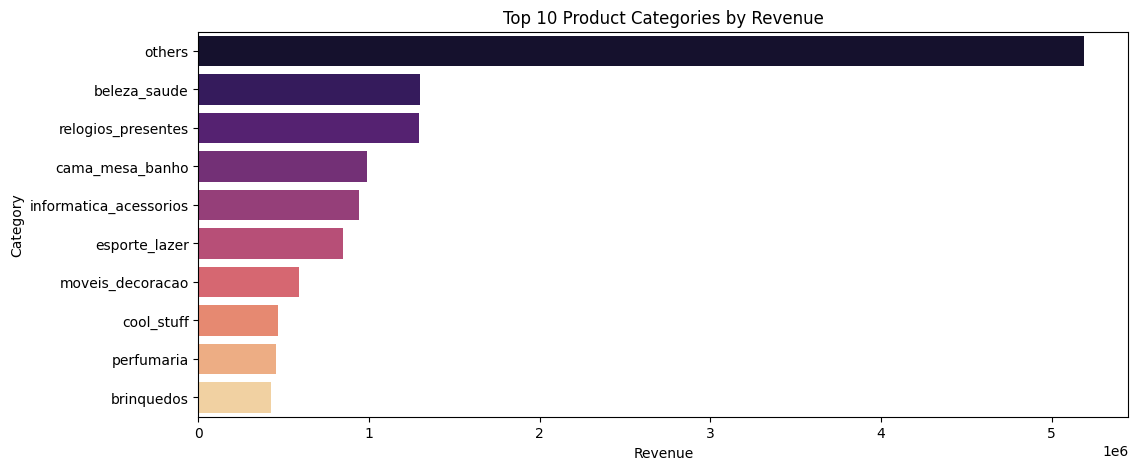

In [73]:
# Top product categories by total sales
top_categories_sales = df_delivery.groupby('product_category_name')['total_order_value'].sum().sort_values(ascending=False).head(10)
print(top_categories_sales)

# Average review score per product category
category_reviews = df_delivery.groupby('product_category_name')['review_score'].mean().sort_values(ascending=False).head(10)
print(category_reviews)

# Visualization
plt.figure(figsize=(12,5))
sns.barplot(x=top_categories_sales.values, y=top_categories_sales.index, palette='magma')
plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Category')
plt.show()

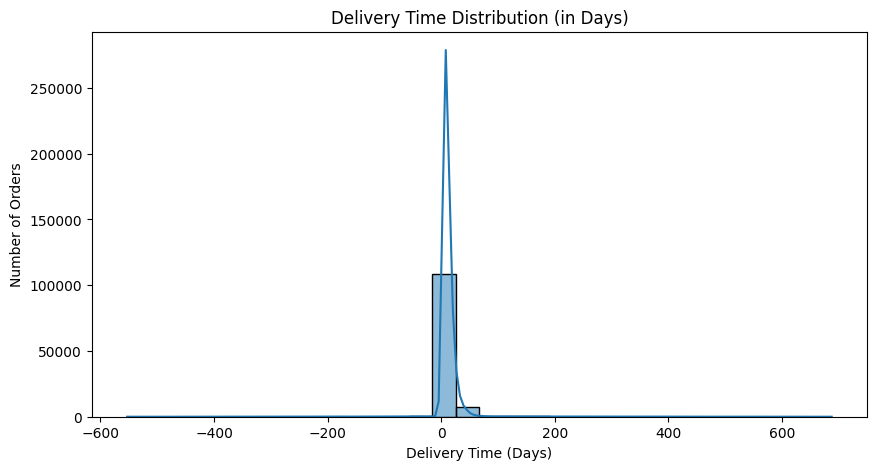

customer_state
Sao Paulo               9.016625
Parana                 12.909486
Distrito Federal       13.043600
Minas Gerais           13.161248
Rio de Janeiro         15.385932
Mato Grosso do Sul     15.467290
Goias                  15.747656
Rio Grande do Sul      16.379933
Espirito Santo         16.606976
Santa Catarina         16.860616
Acre                   17.305263
Mato Grosso            17.351064
Rio Grande do Norte    18.285464
Tocantins              18.501475
Ceará                  19.432519
Pernambuco             19.674382
Bahia                  20.163717
Maranhao               21.250883
Paraiba                21.698438
Sergipe                22.528967
Piaui                  22.567944
Rondônia               24.251748
Para                   24.504898
Amazonas               25.587209
Alagoas                29.993506
Amapa                  32.952381
Roraima                49.769231
Name: delivery_time_days, dtype: float64


In [74]:
# Distribution of delivery time
plt.figure(figsize=(10,5))
sns.histplot(df_delivery['delivery_time_days'], bins=30, kde=True)
plt.title('Delivery Time Distribution (in Days)')
plt.xlabel('Delivery Time (Days)')
plt.ylabel('Number of Orders')
plt.show()

# Average delivery time per state
avg_delivery_state = df_delivery.groupby('customer_state')['delivery_time_days'].mean().sort_values()
print(avg_delivery_state)

payment_type
credit_card    146.421593
debit_card     127.156021
voucher        125.023304
boleto         124.226555
Name: total_order_value, dtype: float64
payment_type
credit_card    87258
boleto         23018
voucher         6332
debit_card      1699
Name: count, dtype: int64


C:\Users\sayya\AppData\Local\Temp\ipykernel_6824\3883860224.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=orders_payment.index, y=orders_payment.values, palette='coolwarm')


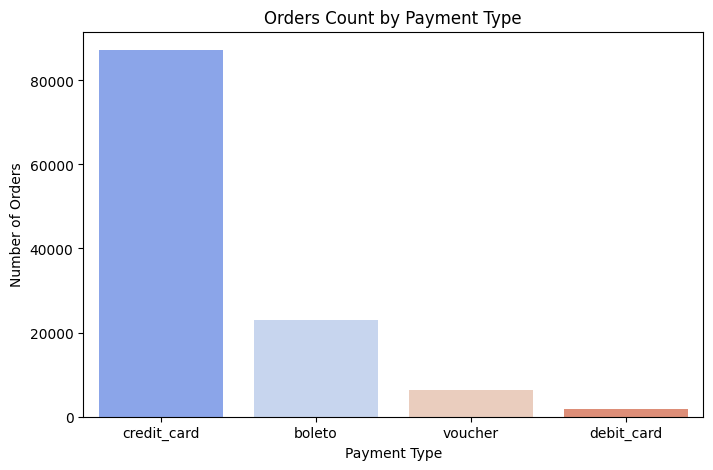

In [75]:
# Average order value by payment type
avg_payment = df_delivery.groupby('payment_type')['total_order_value'].mean().sort_values(ascending=False)
print(avg_payment)

# Number of orders by payment type
orders_payment = df_delivery['payment_type'].value_counts()
print(orders_payment)

# Visualization
plt.figure(figsize=(8,5))
sns.barplot(x=orders_payment.index, y=orders_payment.values, palette='coolwarm')
plt.title('Orders Count by Payment Type')
plt.ylabel('Number of Orders')
plt.xlabel('Payment Type')
plt.show()

is_express_delivery
Normal    93996
Fast      24314
Name: count, dtype: int64
is_express_delivery
Fast      117.569946
Normal    146.656620
Name: total_order_value, dtype: float64


C:\Users\sayya\AppData\Local\Temp\ipykernel_6824\3075769051.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue_delivery_type.index, y=revenue_delivery_type.values, palette='Set2')


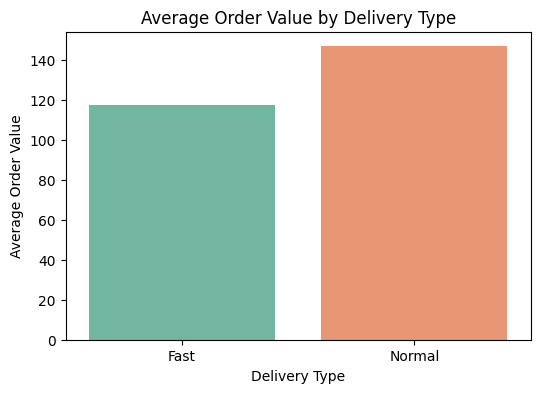

In [76]:
# Count of fast vs normal delivery
delivery_flag_count = df_delivery['is_express_delivery'].value_counts()
print(delivery_flag_count)

# Average revenue per delivery type
revenue_delivery_type = df_delivery.groupby('is_express_delivery')['total_order_value'].mean()
print(revenue_delivery_type)

# Visualization
plt.figure(figsize=(6,4))
sns.barplot(x=revenue_delivery_type.index, y=revenue_delivery_type.values, palette='Set2')
plt.title('Average Order Value by Delivery Type')
plt.ylabel('Average Order Value')
plt.xlabel('Delivery Type')
plt.show()

In [77]:

from sqlalchemy import create_engine
from urllib.parse import quote_plus 

user = 'root'
password = '123456r@'
host = 'localhost'
database = 'ecommerce_db'

password = quote_plus(password)


engine = create_engine(f"mysql+pymysql://{user}:{password}@{host}/{database}")

df.to_sql(
    name='ecommerce_data',   
    con=engine,        
    if_exists='append',
    index=False,       
    chunksize=5000   
)
print("Data imported successfully ✅")

Data imported successfully ✅
